In [1]:
import os
import os.path as op
import sys

import importlib

import numpy as np
import pandas as pd

import nibabel as nib
from nilearn import datasets, image

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpecFromSubplotSpec

from seaborn import kdeplot

from joblib import Parallel, delayed
from tqdm.notebook import tqdm

import networkx as nx
from nilearn.datasets import fetch_atlas_schaefer_2018, fetch_atlas_harvard_oxford, fetch_atlas_yeo_2011
from nilearn.image import resample_to_img

import h5py

import sys
sys.path.append("../..")
path_to_data = op.join("../..", "data")

from bimodularity import dgsp
from bimodularity import bimod_plots as plot
from bimodularity import palettes
from bimodularity import data_load as dload
from bimodularity import bundle as b_utils

In [2]:
path_to_effective = "../../../../effectivedelay_estimation"
path_to_ressources = op.abspath(op.join(path_to_effective, "resources"))
print(path_to_ressources)

out_dir = "../../data/brain/derivatives/atlas_correspondence"
out_dir = op.abspath(out_dir)
os.makedirs(out_dir, exist_ok=True)

os.listdir(out_dir)

/home/acionca/effectivedelay_estimation/resources


['Lobes',
 'custom_Sch400_subcort_atlas.nii.gz',
 'YeoNetworks',
 'rDCM',
 'Laus2018_roi_atlas-ftract-scale2-GM_resampled-fixed.nii.gz']

In [ ]:
sch400 = fetch_atlas_schaefer_2018(n_rois=400, yeo_networks=7, resolution_mm=1)
sch400_img = nib.load(sch400['maps'])
sch400_data = sch400_img.get_fdata()

all_scales = [1, 2, 3, 4]

# labels = np.genfromtxt(op.join(path_to_data, f"{data_suffix}brain_labels-scale{scale}.csv"), dtype=str)

lausanne_list = []
lausanne_resampled = []
lausanne_resampled_old = []
lausanne_data = []
lausanne_pos = []
lausanne_lab = []
for scale in all_scales:
    lausanne_path = op.join(path_to_ressources, f"Laus2018_roi_atlas-ftract-scale{scale}-GM.nii.gz")
    lausanne_list.append(lausanne_path)
    gm_rois = nib.load(lausanne_path)
    resampled = resample_to_img(gm_rois, sch400_img, interpolation='nearest')
    resampled.to_filename(op.join(out_dir, f"Laus2018_roi_atlas-ftract-scale{scale}-GM_resampled.nii.gz"))
    lausanne_resampled_old.append(resampled)
    lausanne_data.append(resampled.get_fdata())
    lausanne_pos.append(dload.load(op.join(path_to_ressources, f"Laus2018_roi_centers-ftract-scale{scale}.pkl")))
    lausanne_lab.append(np.genfromtxt(op.join(path_to_ressources, f"Laus2018_brain_labels-scale{scale}.csv"), dtype=str))

all_reg_sizes = []
for s_i, lab in enumerate(lausanne_lab):
    lausanne_lab[s_i], lausanne_data[s_i], lausanne_pos[s_i] = b_utils.fix_thalamus(labels=lab, atlas_data=lausanne_data[s_i], pos=lausanne_pos[s_i])

    resampled_fixed = nib.Nifti1Image(lausanne_data[s_i].astype(np.int16), affine=lausanne_resampled_old[s_i].affine, header=lausanne_resampled_old[s_i].header)
    resampled_fixed.to_filename(op.join(out_dir, f"Laus2018_roi_atlas-ftract-scale{s_i+1}-GM_resampled-fixed.nii.gz"))
    lausanne_resampled.append(resampled_fixed)

In [ ]:
path_to_EC = "/Users/acionca/code/DMN/data/hcp_rDCM_sch400_extended.mat"

from scipy.io import loadmat

ec_data = loadmat(path_to_EC)
for i, whatev in enumerate(ec_data["results"][0][0]):
    print(i, whatev.shape)
    # print(whatev)

ec_matrix = ec_data["results"][0][0][0]
np.fill_diagonal(ec_matrix, 0)
ec_labels = np.array([lab[0] for lab in ec_data["results"][0][0][7][0]])

subcort_atlas = fetch_atlas_harvard_oxford("sub-maxprob-thr0-1mm")
subcort_labels = subcort_atlas.labels
subcort_data = subcort_atlas.maps.get_fdata()
custom_data = np.zeros_like(subcort_data).astype(np.int16)

lab_hemi = ["LH_" if "Left" in lab else "RH_" for lab in subcort_labels]
lab_name = [lab.split(" ")[1] if len(lab.split(" ")) > 1 else "whatev" for lab in subcort_labels]

custom_labels = []
for i, lab in enumerate(lab_name):
    rename = f"7Networks_{lab_hemi[i]}SubCort_{lab}"

    for j, ec_lab in enumerate(ec_labels):
        if rename in ec_lab:
            # print(f"Found {rename} match {ec_lab} at EC index:", j)
            custom_data[subcort_data == i] = j + 1  # +1 because 0 is background
            custom_labels.append(rename)

sch400_data_tofill = sch400_data.copy()
sch400_data_tofill[sch400_data_tofill > 0] += len(custom_labels)
custom_data[custom_data == 0] = sch400_data_tofill[custom_data == 0]

# custom_img = nib.Nifti1Image(custom_data, subcort_atlas.maps.affine)
custom_img = nib.Nifti1Image(custom_data, sch400_img.affine)
custom_img.set_data_dtype(np.int16)
custom_img.header.set_data_dtype(np.int16)

custom_labels = np.concatenate([np.array(custom_labels).astype(str), sch400['labels'].astype(str)])
all_close = np.zeros(len(custom_labels), dtype=bool)
for i, lab in enumerate(custom_labels):
    all_close[i] = lab == ec_labels[i]

print(f"Are all labels the same: {all_close.all()}")
print(custom_data.max(), custom_data.shape)

custom_img.to_filename(op.join(out_dir, "custom_Sch400_subcort_atlas.nii.gz"))

In [ ]:
lausanne_list

## Volumetric Approach

Below you'll find the code to convert one atlas into another. I was applying the conversion to (effective) connectivity matrices by left- and right- multiplying the connectivity matrix (of size $N_{old} \times N_{old}$) by a correspondence matrix (of size $N_{new} \times N_{old}$) where each entry $c_{ij}$ is the spatial overlap between region $i$ in the new atlas and region $j$ in the old one. You just need to:
1. specify the reference and target atlases (in arrays),
2. compute masks for each region (in each atlas),
3. compute the correspondence matrix using the proportional overlap (almost like the dice),
4. then you can do whatever you want with the matrix.

Hope it helps !

In [ ]:
# Visualization of the atlases (useless)
from nilearn.plotting import plot_roi

cut_coords = (-10, -10, 0)
fig, axes = plt.subplots(nrows=5, figsize=(25, 25))
# plot_roi(sch400['maps'], title="Schaefer 400 ROIs", cmap='tab20', colorbar=True, axes=axes[0])
plot_roi(custom_img, title="Schaefer 414 ROIs (+ Subcorticals)", cmap='turbo', colorbar=True, axes=axes[0], cut_coords=cut_coords, vmax=20)
print(custom_img.affine)

for i, ax in enumerate(axes[1:]):
    # my_img = nib.Nifti1Image(lausanne_data[i], sch400_img.affine)
    my_img = lausanne_resampled[i]
    plot_roi(my_img, title=f"Lausanne Scale {i+1}", cmap='tab20', colorbar=True, axes=ax, cut_coords=cut_coords)
    # plot_roi(lausanne_resampled[i], title=f"Lausanne Scale {i+1}", cmap='tab20', colorbar=True, axes=ax, cut_coords=cut_coords)

print(my_img.affine)

In [ ]:
# Visualization of the atlases (useless)
from nilearn.plotting import plot_roi

cut_coords = (-10, -10, 0)
fig, axes = plt.subplots(nrows=2, figsize=(25, 10))
# plot_roi(sch400['maps'], title="Schaefer 400 ROIs", cmap='tab20', colorbar=True, axes=axes[0])
plot_roi(custom_img, title="Schaefer 414 ROIs (+ Subcorticals)", cmap='turbo', colorbar=True, axes=axes[0], cut_coords=cut_coords)
print(custom_img.affine)

# my_img = nib.Nifti1Image(lausanne_data[i], sch400_img.affine)
my_img = lausanne_resampled[1]
# my_img = nib.load(lausanne_list[1])

disp = plot_roi(my_img, title=f"Lausanne Scale {i+1}", cmap='tab20', colorbar=True, axes=axes[1], cut_coords=cut_coords)
# plot_roi(lausanne_resampled[i], title=f"Lausanne Scale {i+1}", cmap='tab20', colorbar=True, axes=ax, cut_coords=cut_coords)
disp.add_contours(custom_img, filled=False, colors='k', levels=[0.5], linewidths=2, alpha=0.5)

print(my_img.affine)

In [11]:
from tqdm.notebook import tqdm

def make_binary_masks(vol):
    """Create binary masks for a specific label in the volume."""
    n_labels = int(vol.max())
    masks = np.zeros((n_labels, *vol.shape), dtype=int)
    for i in range(1, n_labels + 1):
        masks[i - 1] = (vol == i).astype(int)
    # return masks
    return masks.reshape(n_labels, -1)

def chunked_dice(ref_masks, target_masks, chunk_size=500):
    n_ref = ref_masks.shape[0]
    n_target = target_masks.shape[0]
    n_vox = ref_masks.shape[1]
    
    intersect = np.zeros((n_ref, n_target))
    for start in tqdm(range(0, n_vox, chunk_size)):
        end = min(start + chunk_size, n_vox)
        
        intersect += ref_masks[:, start:end] @ target_masks[:, start:end].T

    # dice_mat = 2 * intersect / (ref_masks.sum(axis=1)[:, None] + target_masks.sum(axis=1)[None, :] + 1e-10)
    dice_mat = intersect / target_masks.sum(axis=1)
    return dice_mat

## DEFINE YOUR REFERENCE ATLAS AND TARGET ATLAS HERE
## THE COMPUTATION OF THE MASK HAPPENS BELOW

path_to_hcp = "/media/RCPNAS/HCP-data/HCP_100unrelated_preprocessed_ERG"
path_to_atlas = op.join(path_to_hcp, f"Misc/Parcs/Glasser")
path_to_subc = op.join(path_to_atlas, f"Glasser_subc.nii")

glasser_img = nib.load(path_to_subc)
glasser_data = glasser_img.get_fdata()

path_to_lausanne = "/home/acionca/code/Bimodularity/data/brain/derivatives/atlas_correspondence/Laus2018_roi_atlas-ftract-scale2-GM_resampled-fixed.nii.gz"
lausanne_img = nib.load(path_to_lausanne)
lausanne_img_resampled = resample_to_img(lausanne_img, glasser_img, interpolation='nearest')
lausanne_data = lausanne_img_resampled.get_fdata()

laus_mask = make_binary_masks(lausanne_data)
glasser_mask = make_binary_masks(glasser_data)

# sch400_masks = make_binary_masks(sch400_data)
# sch400_masks = make_binary_masks(custom_data)
# lausanne_masks_list_orig = [make_binary_masks(lausanne_data[i]) for i in range(len(all_scales))]

# nzer = (sch400_masks.sum(axis=0) > 0)
# for laus in lausanne_masks_list_orig:
#     nzer = np.logical_or(laus.sum(axis=0) > 0, nzer)

# sch400_masks = sch400_masks[:, nzer]
# lausanne_masks_list = [laus[:, nzer] for laus in lausanne_masks_list_orig]

/tmp/ipykernel_1582784/1904432247.py:39: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  lausanne_img_resampled = resample_to_img(lausanne_img, glasser_img, interpolation='nearest')
/home/acionca/.conda/envs/ni_utils/lib/python3.13/site-packages/nilearn/image/resampling.py:805: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  return resample_img(


In [14]:
g2l_dice = chunked_dice(glasser_mask, laus_mask, chunk_size=50)

  0%|          | 0/18053 [00:00<?, ?it/s]

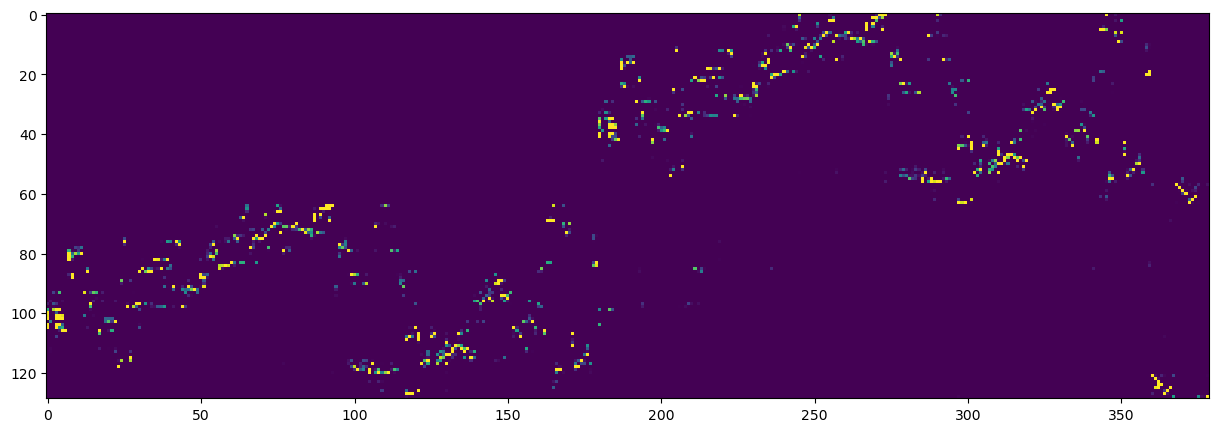

In [23]:
fig, axes = plt.subplots(figsize=(15, 5))

axes.imshow(g2l_dice.T, aspect='auto', cmap='viridis', interpolation="none", vmax=0.1)

np.savetxt("/home/acionca/atlases/glasser2lausanne_dice_Amax.csv", np.argmax(g2l_dice, axis=0), delimiter=",", fmt="%d")

In [ ]:
## MAKE SURE ALL MASKS HAVE THE SAME SIZE (nvoxels)
print(sch400_masks.shape)
print(lausanne_masks_list[0].shape)

In [ ]:
## UNCOMMENT BELOW TO COMPUTE THE DICE MATRIX (OR MATRICES IF MULTIPLE TARGET ATLAS)

# c_dice = chunked_dice(sch400_masks, lausanne_masks_list[0])
# all_dices_byLaus = [chunked_dice(sch400_masks, l_mask, chunk_size=50).T for l_mask in lausanne_masks_list]

all_dices_byLaus = [chunked_dice(sch400_masks, lausanne_masks_list[1], chunk_size=50).T]

In [ ]:
fig, axes = plt.subplots(ncols=len(lausanne_masks_list), figsize=(24, 6))

for ax, c_dice in zip(axes, all_dices_byLaus):
    # row, col = linear_sum_assignment(c_dice, maximize=True)
    # ax.imshow(c_dice[row][:, col], cmap='magma', aspect="auto", interpolation='none')
    ax.imshow(c_dice, cmap='magma', aspect="auto", interpolation='none')
    plot.add_cbar(fig, ax)

In [ ]:
# all_dices_bySch = [chunked_dice(l_mask, sch400_masks, chunk_size=50) for l_mask in lausanne_masks_list]

all_dices_bySch = [chunked_dice(lausanne_masks_list[1], sch400_masks, chunk_size=50)]

In [ ]:
fig, axes = plt.subplots(ncols=len(lausanne_masks_list), figsize=(24, 6))

for ax, c_dice in zip(axes, all_dices_bySch):
    # row, col = linear_sum_assignment(c_dice, maximize=True)
    # ax.imshow(c_dice[row][:, col], cmap='magma', aspect="auto", interpolation='none')
    ax.imshow(c_dice, cmap='magma', aspect="auto", interpolation='none')
    plot.add_cbar(fig, ax)

In [ ]:
all_dices = [d for d in all_dices_byLaus]

In [ ]:
fig, axes = plt.subplots(ncols=len(lausanne_masks_list), figsize=(24, 6), sharey=True, gridspec_kw={"wspace": 0})

for ax, c_dice in zip(axes, all_dices):
    scatter_values = c_dice.max(axis=1)
    ax.plot(scatter_values, marker='o')

    ax.plot([0, len(scatter_values)], [scatter_values.mean()]*2, color="k", ls="--")
    ax.plot([0, len(scatter_values)], [np.median(scatter_values)]*2, color="k")
    
    # ax.plot(np.percentile(c_dice, 99.9, axis=0), marker='o')
    # ax.plot(c_dice[14:].max(axis=0), marker='o', color="tab:green")

for i, ax in enumerate(axes):
    ax.set_title(f"Lausanne Scale {i+1}")
    ax.set_xlabel("Lausanne2018 Index")
    if i == 0:
        ax.set_ylabel("Max Dice Coefficient")

In [ ]:
c_dice = all_dices[0]
l_labs = lausanne_lab[1]
l_data = lausanne_data[1]

fig, axes = plt.subplots(figsize=(25, 6))

axes.plot(c_dice.max(axis=1), color="tab:blue", label="Max Dice", zorder=0)
for i, c_d in enumerate(c_dice):
    axes.scatter(np.zeros_like(c_d) + i, c_d, s=50, color="tab:blue", edgecolors="none", alpha=c_d/c_d.max())

print(f"Worst matching labels:")
l_labs[np.argsort(c_dice.max(axis=1))[:10]]
# l_labs[-1]

In [ ]:
custom_voxel_size = np.zeros(len(custom_labels), dtype=int)

for i in range(len(custom_labels)):
    custom_voxel_size[i] = np.sum(custom_data == (i+1))

lausanne_voxel_size = np.zeros(len(lausanne_lab[1]), dtype=int)
for i in range(len(lausanne_lab[1])):
    lausanne_voxel_size[i] = np.sum(lausanne_data[1] == (i+1))

norm_dice = c_dice / c_dice.sum(axis=1)[:, None]
# norm_n_voxel = norm_dice @ custom_voxel_size
norm_n_voxel = norm_dice @ custom_voxel_size

thresh = 0.5
thresh = np.percentile(c_dice, 90)
print(thresh)
n_thresh = np.sum(c_dice > thresh, axis=1)

fig, axes = plt.subplots(figsize=(25, 6))

axes.plot(c_dice.max(axis=1), color="tab:blue", label="Max Dice", zorder=0)
for i, c_d in enumerate(c_dice):
    axes.scatter(np.zeros_like(c_d) + i, c_d, label=custom_labels[i], s=50, color="tab:blue", edgecolors="none", alpha=c_d/c_d.max())

axes2 = axes.twinx()
axes2.plot(norm_n_voxel, color="tab:red", label="Normalized Voxel Count", zorder=0)

axes2.plot([0, len(norm_n_voxel)], [np.median(norm_n_voxel)]*2, color="tab:red", zorder=1)
axes2.plot([0, len(norm_n_voxel)], [norm_n_voxel.mean()]*2, color="tab:red", zorder=1, ls="--")

axes3 = axes.twinx()
axes3.plot(n_thresh, color="tab:green", label=f"Number of Dice > {thresh}", zorder=0)
axes3.plot([0, len(n_thresh)], [np.median(n_thresh)]*2, color="tab:green", zorder=1)

n_below_half = (c_dice.max(axis=1) < 0.5).sum()
n_below_half = 10
print(f"{n_below_half} labels have max dice below 0.5 (out of {len(c_dice)})")

print(f"Worst matching labels:")
for i in np.argsort(c_dice.max(axis=1))[:n_below_half + 1]:
    print(f"  - {l_labs[i]}: {c_dice.max(axis=1)[i]:.2f}")

print(f"\nHighest Normalized Voxel Count:")
for i in np.flip(np.argsort(norm_n_voxel))[:n_below_half + 1]:
    print(f"  - {l_labs[i]}: {norm_n_voxel[i]:.2f}")

print(f"\nHighest Number of Dice > {thresh}:")
for i in np.flip(np.argsort(n_thresh))[:n_below_half + 1]:
    print(f"  - {l_labs[i]}: {n_thresh[i]}")

In [ ]:
fig, axes = plt.subplots(ncols=3, figsize=(18, 6))

for i, ax in enumerate(axes[:-1]):
    d = [all_dices_bySch[0], all_dices_byLaus[0]][i]

    # nd = d / d.sum(axis=1)[:, None]
    nd = d / d.sum(axis=0)[None, :]

    # if i > 0:
    #     nd = nd.T

    norm_n_voxel = nd @ custom_voxel_size

    ax.scatter(lausanne_voxel_size[:-1], norm_n_voxel[:-1], color="tab:blue", s=20, alpha=0.5, edgecolors="none")
    ax.set_xlabel("Lausanne2018 Voxel Count")
    ax.set_ylabel("Norm. Voxel Count in Schaefer400")
    ax.set_title(["Norm. Schaefer414", "Norm. Lausanne2018"][i])

axes[-1].scatter(all_dices_bySch[0], all_dices_byLaus[0], alpha=0.5, color="tab:blue", edgecolors="none")

In [ ]:
from nilearn.plotting import plot_roi, plot_anat
importlib.reload(plot)

fig, all_axes = plt.subplots(nrows=2, figsize=(22, 10), gridspec_kw={"hspace": 0.1, "height_ratios": [1, 1.5]})
# fig, axes = plt.subplots(ncols=2, figsize=(22, 5), gridspec_kw={"wspace": 0})

for ax in all_axes:
    ax.axis("off")

gs = GridSpecFromSubplotSpec(1, 2, subplot_spec=all_axes[0].get_subplotspec(), wspace=0)
axes_atlas =[fig.add_subplot(gs[i], facecolor="none") for i in range(2)]

atlas_imgs = [custom_img, lausanne_resampled[1]]
atlas_titles = ["Schaefer 414 Parcels", "Lausanne 2018 - Scale 2 Parcels"]
for i, ax in enumerate(axes_atlas):
    # plot_roi(atlas_imgs[i], axes=ax, display_mode="y", cut_coords=[-10], annotate=False, alpha=0.9) #, view_type="contours", linewidths=1)
    plot_roi(atlas_imgs[i], axes=ax, cut_coords=[35, -10, 10], alpha=0.9, draw_cross=False, annotate=False) #, view_type="contours", linewidths=1)
    ax.set_title(atlas_titles[i], fontsize=20, ha="left", x=0.05, y=0.8)

# fig, axes = plt.subplots(ncols=4, figsize=(22, 5), gridspec_kw={"wspace": 0.4, "width_ratios": [1, 1, 1, 1.2]})
gs = GridSpecFromSubplotSpec(1, 4, subplot_spec=all_axes[1].get_subplotspec(), wspace=0.4, width_ratios=[1, 1, 1, 1.2])
axes =[fig.add_subplot(gs[i]) for i in range(4)]

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[:].set_linewidth(2)
    ax.tick_params(width=2, labelsize=14)

rand_seed = 24
np.random.seed(rand_seed)
rand_w = 0.5

all_vals = [all_dices_bySch[0].max(axis=0), c_dice.sum(axis=1), norm_n_voxel]
all_titles = ["Proportional Voxel Overlap", "Proportional Target Coverage", "Normalized Mapped Voxel Count"]

color = "grey"
for i, (ax, val, title) in enumerate(zip(axes, all_vals, all_titles)):
    # x_scatter = np.random.uniform(-rand_w, rand_w, size=val.shape)
    x_scatter = np.random.uniform(-rand_w, 0, size=val.shape)

    print(val.shape)
    
    ax.scatter(x_scatter, val, s=40, alpha=0.6, edgecolors="none", color=color, label=title, zorder=0)
    plot.plot_kde(val, vertical=True, ax=ax, color=color, lw=4, bw_adjust=0.3, alpha=0.5)

    # ax.plot([-rand_w, 1], [np.mean(val)]*2, color="k", ls="--", lw=2, zorder=2)
    ax.plot([-rand_w, 1], [np.median(val)]*2, color="k", lw=4, zorder=2)

    # ax.text(1, np.mean(val) * 1.1, f"Mean: {np.mean(val):.2f}", ha="right", va="center", fontsize=12)
    ax.text(1.3, np.median(val) - 0.05 * np.max(val), f"Median: {np.median(val):.2f}", ha="right", va="center", fontsize=14)

    ax.set_xlim(-0.9, 1.4)
    ax.set_ylabel(title, fontsize=16)
    ax.set_xticks([])

axes[0].set_ylim(-0.05, 1.05)

axes[0].set_title("Schaefer 414", fontsize=18)
for ax in axes[1:]:
    ax.set_title("Lausanne 2018", fontsize=18)

axes[-1].scatter(lausanne_voxel_size, norm_n_voxel, s=40, alpha=0.6, edgecolors="none", color=color)
axes[-1].plot([0, 20000], [0, 20000], color="k", lw=2)

# axes[-1].legend(["Lausanne2018 Parcels"], fontsize=14)
axes[-1].set_xlabel("Original Voxel Count", fontsize=16)
axes[-1].set_ylabel("Normalized Mapped Voxel Count", fontsize=16)

In [ ]:
print(np.sum(c_dice.sum(axis=1) > 0.8) / len(c_dice))
print(np.sum(c_dice.sum(axis=1) > 0.8))

In [ ]:
from nilearn.plotting import plot_roi, plot_anat

fig, axes = plt.subplots(ncols=2, figsize=(22, 5), gridspec_kw={"wspace": 0})

atlas_imgs = [custom_img, lausanne_resampled[1]]
atlas_titles = ["Schaefer 414", "Lausanne 2018 - Scale 2"]
for i, ax in enumerate(axes):
    # plot_roi(atlas_imgs[i], axes=ax, display_mode="y", cut_coords=[-10], annotate=False, alpha=0.9) #, view_type="contours", linewidths=1)
    plot_roi(atlas_imgs[i], axes=ax, cut_coords=[35, -10, 10], alpha=0.9, draw_cross=False, annotate=False) #, view_type="contours", linewidths=1)
    ax.set_title(atlas_titles[i], fontsize=20, ha="left", x=0.05)

In [ ]:
from nilearn.surface import vol_to_surf, load_surf_mesh, load_surf_data
from nilearn.plotting import plot_surf_stat_map, plot_surf_roi
from nilearn.datasets import fetch_surf_fsaverage

fsavg = fetch_surf_fsaverage("fsaverage5")

print(fsavg.keys())

surf_lab = "infl_left"
surf_lab = "pial_left"
curv_lab = "curv_left"
# curv_lab = "sulc_left"

surf = load_surf_mesh(fsavg[surf_lab])
curv = load_surf_data(fsavg[curv_lab])

fig, axes = plt.subplots(ncols=2, figsize=(10, 5), subplot_kw={"projection": "3d"})

atlas_imgs = [custom_img, lausanne_resampled[1]]
for i, ax in enumerate(axes):
    atlas_in_surf = vol_to_surf(atlas_imgs[i], fsavg["pial_left"], radius=3, interpolation="nearest", inner_mesh=fsavg["white_left"], depth=[0, -0.5])

    # disp = plot_surf_stat_map(surf, np.ones(surf[0].shape[0]), bg_map=curv, hemi="left", view="lateral", colorbar=True, cmap="viridis", axes=axes)
    disp = plot_surf_roi(surf, atlas_in_surf, bg_map=curv, hemi="left", view="lateral", colorbar=True, axes=ax, bg_on_data=True, darkness=1, cmap="prism")

In [ ]:
n_below_half = (c_dice.max(axis=1) < 0.5).sum()
print(f"{n_below_half} labels have max dice below 0.5 (out of {len(c_dice)})")

print(f"Worst matching labels:")
for i in np.argsort(c_dice.max(axis=1))[:n_below_half + 1]:
    print(f"  - {l_labs[i]}: {c_dice.max(axis=1)[i]:.2f}")

print(f"\nHighest Normalized Voxel Count:")
for i in np.flip(np.argsort(norm_n_voxel))[:n_below_half + 1]:
    print(f"  - {l_labs[i]}: {norm_n_voxel[i]:.2f}")

print(f"\nHighest Number of Dice > {thresh}:")
for i in np.flip(np.argsort(n_thresh))[:n_below_half + 1]:
    print(f"  - {l_labs[i]}: {n_thresh[i]}")

## Converting the EC

In [ ]:
# path_to_EC = "/Users/acionca/data/Laminar_organization/src/hcp_rDCM_sch400.mat"

# from scipy.io import loadmat

# ec_data = loadmat(path_to_EC)
# for i, whatev in enumerate(ec_data["results"][0][0]):
#     print(i, whatev.shape)
#     # print(whatev)

# ec_matrix = ec_data["results"][0][0][0]
# np.fill_diagonal(ec_matrix, 0)
# ec_labels = ec_data["results"][0][0][7].flatten()

In [ ]:
rDCM_out = op.join(out_dir, "rDCM")
os.makedirs(rDCM_out, exist_ok=True)

dice_mat = all_dices_byLaus[0]
norm_dice = dice_mat / dice_mat.sum(axis=1)[:, None]

ec_conv = norm_dice @ ec_matrix @ norm_dice.T
ec_conv = np.nan_to_num(ec_conv)
print(ec_conv.shape)

# ## MAKE SURE TO TRANSPOSE BECAUSE EC IS FROM COL TO ROW !!!
# ec_conv = ec_conv.T

dload.save(op.join(rDCM_out, f"Laus2018_EffConnFromSch414-scale2OneThal-overlap.pkl"), {"conv": ec_conv.T, "dice": dice_mat, "overlap_laus": all_dices_byLaus[0], "overlap_sch": all_dices_bySch[0]})

In [ ]:
## HERE IS THE CONVERSION OF THE CONNECTIVITY MATRIX (IN EC_MATRIX)
all_conv_ec = []

rDCM_out = op.join(out_dir, "rDCM")
os.makedirs(rDCM_out, exist_ok=True)

# for i, dice_mat in enumerate(all_dices):
for i, dice_mat in enumerate(all_dices_byLaus):
    # norm_dice = dice_mat / dice_mat.sum(axis=0)[None, :]
    norm_dice = dice_mat / dice_mat.sum(axis=1)[:, None]

    # ec_conv = norm_dice.T @ ec_matrix @ norm_dice
    ec_conv = norm_dice @ ec_matrix @ norm_dice.T
    ec_conv = np.nan_to_num(ec_conv)
    print(ec_conv.shape)
    
    ## MAKE SURE TO TRANSPOSE BECAUSE EC IS FROM COL TO ROW !!!
    all_conv_ec.append(ec_conv.T)

    # dload.save(op.join(out_dir, f"Laus2018_EffConnFromSch400-scale{scale}.pkl"), {"conv": ec_conv, "dice": dice_mat})
    dload.save(op.join(rDCM_out, f"Laus2018_EffConnFromSch414-scale{i+1}OneThal.pkl"), {"conv": ec_conv.T, "dice": dice_mat, "overlap_laus": all_dices_byLaus[i], "overlap_sch": all_dices_bySch[i]})

fig, axes = plt.subplots(ncols=len(all_conv_ec), nrows=3, figsize=(24, 12), gridspec_kw={'hspace': 0})

maxval = np.abs(ec_matrix).max()
axes[0, 0].imshow(ec_matrix, cmap='RdBu_r', interpolation="none", vmin=-0.8*maxval, vmax=0.8*maxval)
axes[0, 1].imshow(ec_matrix, cmap='RdBu_r', interpolation="none", vmin=-0.8*maxval, vmax=0.8*maxval)
axes[0, 2].imshow(ec_matrix - ec_matrix.T, cmap='RdBu_r', interpolation="none", vmin=-0.1*maxval, vmax=0.1*maxval)
axes[0, 3].imshow(ec_matrix - ec_matrix.T, cmap='RdBu_r', interpolation="none", vmin=-0.1*maxval, vmax=0.1*maxval)

# maxval = 0.2
for ax, conv_ec in zip(axes[1], all_conv_ec):
    maxval = np.abs(conv_ec).max() * 0.6
    ax.imshow(conv_ec, cmap='RdBu_r', interpolation="none", vmin=-maxval, vmax=maxval)
    plot.add_cbar(fig, ax)

for ax, conv_ec in zip(axes[2], all_conv_ec):
    diff = conv_ec - conv_ec.T
    maxval = np.abs(diff).max() * 0.6
    ax.imshow(diff, cmap='RdBu_r', interpolation="none", vmin=-maxval, vmax=maxval)
    plot.add_cbar(fig, ax)

In [ ]:
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(24, 15), gridspec_kw={'hspace': 0, 'wspace': 0.1, "height_ratios": [1.8, 1.1, 1]})

orig_cmap = plt.get_cmap("vanimo", 10)
custom_cmap = LinearSegmentedColormap.from_list("custom_vanimo", [orig_cmap(1), "w", orig_cmap(8)])
custom_cmap = LinearSegmentedColormap.from_list("custom_vanimo", ["orchid", "w", "forestgreen"])

vmax = 0.6
for i, conv in enumerate(all_conv_ec):
    out_deg = conv.sum(axis=1)
    in_deg = conv.sum(axis=0)

    # diff = out_deg - in_deg
    diff = out_deg / (out_deg + in_deg)
    diff[np.isnan(diff)] = 0.5
    diff = diff.real
    
   #  vmax = diff.max()
    vmin = 1 - vmax

    pos = lausanne_pos[i]
    sorting = np.argsort(pos[:, 2])
    axes[0, i].scatter(pos[sorting, 0], pos[sorting, 1], s=200, c=diff[sorting], cmap=custom_cmap, edgecolor="k",
                       vmin=vmin, vmax=vmax)
                    #    vmin=-np.max(np.abs(diff)), vmax=np.max(np.abs(diff)))
    sorting = np.argsort(pos[:, 1])
    axes[1, i].scatter(pos[sorting, 0], pos[sorting, 2], s=200, c=diff[sorting], cmap=custom_cmap, edgecolor="k",
                       vmin=vmin, vmax=vmax)
                    #    vmin=-np.max(np.abs(diff)), vmax=np.max(np.abs(diff)))
   #  axes[1, i].set_ylim(-80, 100)
    sorting = np.argsort(pos[:, 0])
    axes[2, i].scatter(pos[sorting, 1], pos[sorting, 2], s=200, c=diff[sorting], cmap=custom_cmap, edgecolor="k",
                       vmin=vmin, vmax=vmax)
                    #    vmin=-np.max(np.abs(diff)), vmax=np.max(np.abs(diff)))
   #  axes[2, i].set_ylim(-80, 100)

for x_pos in [0.3, 0.5, 0.7]:
   cbar_pos = [x_pos, 0.48, 0.02, 0.12]
   cbar_ax = fig.add_axes(cbar_pos)
   cbar = plt.colorbar(plt.cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax)), cax=cbar_ax)

for ax in axes.flatten():
    ax.axis("off")

In [ ]:
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(24, 15), gridspec_kw={'hspace': 0, 'wspace': 0.1, "height_ratios": [1.8, 1.1, 1]})

orig_cmap = plt.get_cmap("vanimo", 10)
custom_cmap = LinearSegmentedColormap.from_list("custom_vanimo", [orig_cmap(1), "w", orig_cmap(8)])
custom_cmap = LinearSegmentedColormap.from_list("custom_vanimo", ["orchid", "w", "forestgreen"])

vmax = 0.6
for i, conv in enumerate(all_conv_ec):
    out_deg = conv.sum(axis=1)
    in_deg = conv.sum(axis=0)

    # diff = out_deg - in_deg
    diff = out_deg / (out_deg + in_deg)
    diff[np.isnan(diff)] = 0.5
    diff = diff.real
    
   #  vmax = diff.max()
    vmin = 1 - vmax

    pos = lausanne_pos[i]
    sorting = np.argsort(pos[:, 2])
    axes[0, i].scatter(pos[sorting, 0], pos[sorting, 1], s=200, c=diff[sorting], cmap=custom_cmap, edgecolor="k",
                       vmin=vmin, vmax=vmax)
                    #    vmin=-np.max(np.abs(diff)), vmax=np.max(np.abs(diff)))
    sorting = np.argsort(pos[:, 1])
    axes[1, i].scatter(pos[sorting, 0], pos[sorting, 2], s=200, c=diff[sorting], cmap=custom_cmap, edgecolor="k",
                       vmin=vmin, vmax=vmax)
                    #    vmin=-np.max(np.abs(diff)), vmax=np.max(np.abs(diff)))
   #  axes[1, i].set_ylim(-80, 100)
    sorting = np.argsort(pos[:, 0])
    axes[2, i].scatter(pos[sorting, 1], pos[sorting, 2], s=200, c=diff[sorting], cmap=custom_cmap, edgecolor="k",
                       vmin=vmin, vmax=vmax)
                    #    vmin=-np.max(np.abs(diff)), vmax=np.max(np.abs(diff)))
   #  axes[2, i].set_ylim(-80, 100)

for x_pos in [0.3, 0.5, 0.7]:
   cbar_pos = [x_pos, 0.48, 0.02, 0.12]
   cbar_ax = fig.add_axes(cbar_pos)
   cbar = plt.colorbar(plt.cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax)), cax=cbar_ax)

for ax in axes.flatten():
    ax.axis("off")

## Converting Yeo into Laus2018

In [ ]:
yeo_maps = fetch_atlas_yeo_2011()
print(yeo_maps.keys())

yeo7 = yeo_maps["thick_7"]
yeo7 = yeo_maps["thick_17"]
print(yeo7)
yeo7_img = nib.load(yeo7)
yeo7_resampled = resample_to_img(yeo7_img, lausanne_resampled[0], interpolation='nearest')

yeo7_data = yeo7_resampled.get_fdata()[..., 0]
n_yeo = yeo7_data.max().astype(int)
print(n_yeo)

# yeo_labels = np.genfromtxt(yeo_maps["colors_7"], dtype=str)
# yeo_labels = ["Unknown", "Visual", "Somatomotor", "Dorsal Attention", "Ventral Attention", "Limbic", "Frontoparietal", "Default"]

if n_yeo == 7:
    yeo_labels = ["Visual", "Somatomotor",
                  "Dorsal Attention", "Ventral Attention",
                  "Limbic", "Frontoparietal", "Default"]
else:
    yeo_labels = ["VisPeri", "VisCent",
                  "SomMotA", "SomMotB",
                  "DorsAttnA", "DorsAttnB",
                  "VentAttn", "Salience",
                  "LimbicA", "LimbicB",
                  "ContC", "ContA", "ContB",
                  "DefaultD", "DefaultC", "DefaultA", "DefaultB"]

yeo_labels += ["Subcortical"]
yeo_labels

In [ ]:
from nilearn.plotting import plot_anat

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 5))
axes = axes.flatten()

yeo7_data.shape
for i, d in enumerate(lausanne_data):
    disp = plot_anat(yeo7_resampled, axes=axes[i])
    disp.add_overlay(lausanne_resampled[i], cmap='gist_ncar', alpha=0.5)
    # axes[i].imshow(yeo7_data.max(axis=-1), cmap='binary_r')
    # axes[i].imshow(d.max(axis=-1), cmap='magma', alpha=0.5)


In [ ]:
# sch400_masks = make_binary_masks(custom_data)
yeo_masks = make_binary_masks(yeo7_data)
# lausanne_masks_list_orig = [make_binary_masks(lausanne_data[i]) for i in range(len(all_scales))]

nzer = (yeo_masks.sum(axis=0) > 0)
for laus in lausanne_masks_list_orig:
    nzer = np.logical_or(laus.sum(axis=0) > 0, nzer)

yeo_masks = yeo_masks[:, nzer]
lausanne_masks_list = [laus[:, nzer] for laus in lausanne_masks_list_orig]

print(yeo_masks.shape)
lausanne_masks_list[0].shape

# all_dices = [chunked_dice(sch400_masks, l_mask, chunk_size=50) for l_mask in lausanne_masks_list]
all_dices = [chunked_dice(yeo_masks, l_mask, chunk_size=50) for l_mask in lausanne_masks_list]

In [ ]:
# Fixing subcortical to subcortical 
fixed_dices = []
for i, scale in enumerate(all_scales):
    subc_dice = np.zeros(all_dices[i].shape[1])
    for j, lab in enumerate(lausanne_lab[i]):
        if "subc" in lab or "stem" in lab:
            subc_dice[j] = 1.0

    all_dices[i][:, subc_dice > 0] = 0.0
    fixdice = np.concatenate([all_dices[i], [subc_dice]], axis=0)
    fixed_dices.append(fixdice)

In [ ]:
fig, axes = plt.subplots(ncols=len(lausanne_masks_list), figsize=(24, 6))

yeo_out = op.join(out_dir, "YeoNetworks")
os.makedirs(yeo_out, exist_ok=True)

# for i, c_dice in enumerate(all_dices):
for i, c_dice in enumerate(fixed_dices):
    axes[i].imshow(c_dice, cmap='magma', aspect="auto", interpolation='none')
    plot.add_cbar(fig, axes[i])
    dload.save(op.join(yeo_out, f"Laus2018_Yeo{n_yeo}-scale{i+1}OneThal.pkl"), {"dice": c_dice, "labels": yeo_labels})

## Correspondence with Lobes

In [ ]:
path_to_lobes = "/Users/acionca/fsl/data/atlases/MNI"
lobe_fname = op.join(path_to_lobes, "MNI-maxprob-thr0-1mm.nii.gz")

lobe_names = [
    "caudate", "cerebellum", "frontal lobe", "insula", "occipital lobe", "parietal lobe", "putamen", "temporal lobe", "thalamus",
]

lobe_img = nib.load(lobe_fname)
lobe_data = lobe_img.get_fdata()

hemi_cut = lobe_data.shape[0] // 2 - 2

lobe_data_split = lobe_data.copy()
lobe_data_split[:hemi_cut] += len(lobe_names)
lobe_data_split[lobe_data == 0] = 0

lobe_names_extended = [f"{hemi}-" + "_".join(l.split(" ")) for hemi in ["lh", "rh"] for l in lobe_names]

print(lobe_names_extended)

lobe_split_img = nib.Nifti1Image(lobe_data_split, lobe_img.affine)
lobe_split_img.set_data_dtype(np.int16)
lobe_split_img.header.set_data_dtype(np.int16)

plot_roi(lobe_split_img, title="MNI Lobes Split by Hemisphere", cmap='tab20', colorbar=True, vmax=21)

In [ ]:
lobe_masks = make_binary_masks(lobe_data_split)
# lausanne_masks_list = [make_binary_masks(lausanne_data[i]) for i in range(len(all_scales))]

nzer = (lobe_masks.sum(axis=0) > 0)
for laus in lausanne_masks_list_orig:
    nzer = np.logical_or(laus.sum(axis=0) > 0, nzer)

lobe_masks = lobe_masks[:, nzer]
lausanne_masks_list = [laus[:, nzer] for laus in lausanne_masks_list_orig]

print(lobe_masks.shape)
print(lausanne_masks_list[0].shape)

all_dices = [chunked_dice(lobe_masks, l_mask, chunk_size=50) for l_mask in lausanne_masks_list]

In [ ]:
fig, axes = plt.subplots(ncols=len(lausanne_masks_list), figsize=(24, 6))

lobes_out = op.join(out_dir, "Lobes")
os.makedirs(lobes_out, exist_ok=True)

for i, c_dice in enumerate(all_dices):
    axes[i].imshow(c_dice, cmap='magma', aspect="auto", interpolation='none')
    plot.add_cbar(fig, axes[i])
    dload.save(op.join(lobes_out, f"Laus2018_LobeMNI-scale{i+1}OneThal.pkl"), {"dice": c_dice, "labels": lobe_names_extended})